# SkinCare AI — Final Deep Learning Notebook

## CNN-Based Preliminary Skin Disease Classification

This notebook presents the final version of the SkinCare AI project.

The goal of this project is to classify dermatological images into four selected skin disease categories using Deep Learning and Computer Vision techniques.

The selected classes are:
- Acne
- Eczema
- Psoriasis
- Rosacea

Several deep learning models were tested in draft notebooks, including:
- Simple CNN
- Improved CNN with Dropout and Batch Normalization
- MobileNetV2 Transfer Learning
- MobileNetV2 Fine-Tuning

The final selected model is MobileNetV2 after the first transfer learning phase.

## Problem Statement

Skin disease classification from images is a challenging Computer Vision task because several dermatological conditions may share similar visual patterns such as redness, inflammation, plaques or skin texture changes.

Manual analysis usually requires medical expertise. This project proposes a Deep Learning-based system for preliminary image classification of skin conditions.

The system is not intended to replace a dermatologist diagnosis. It is designed only for educational and preliminary classification purposes.

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix

2026-05-17 00:16:02.477971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778976962.698510      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778976962.764869      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778976963.331079      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778976963.331136      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778976963.331139      57 computation_placer.cc:177] computation placer alr

In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: []


2026-05-17 00:16:30.101128: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Dataset Description

The dataset used in this project is the Skin Disease Dataset from Kaggle.

The original dataset contains multiple skin disease categories. After visual inspection and project scoping, four classes were selected:

- Acne
- Eczema
- Psoriasis
- Rosacea

The `Unknown_Normal` class was excluded because it contained several non-skin images, which could introduce noise into the training process.

In [5]:
DATASET_PATH = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


In [6]:
SELECTED_CLASSES = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Rosacea"
]

NUM_CLASSES = len(SELECTED_CLASSES)

print("Selected classes:", SELECTED_CLASSES)
print("Number of classes:", NUM_CLASSES)

Selected classes: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea']
Number of classes: 4


## Data Preprocessing

Images were resized to 224 × 224 pixels to match the input size expected by MobileNetV2.

For MobileNetV2, the `preprocess_input` function was used instead of simple normalization. This preprocessing converts image pixels into the format expected by the pre-trained MobileNetV2 model.

The training set was split into training and validation subsets. The test set was used only for final evaluation.

In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 2143 images belonging to 4 classes.
Found 534 images belonging to 4 classes.
Found 293 images belonging to 4 classes.
Class indices: {'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3}


## Models Tested

Several models were tested during the experimentation phase:

| Model | Test Accuracy | Observation |
|---|---:|---|
| Simple CNN | 51.88% | Baseline model, overfitting observed |
| Improved CNN with Dropout and Batch Normalization | 24.23% | Poor generalization, biased predictions |
| MobileNetV2 Transfer Learning — Phase 1 | 71% | Best model |
| MobileNetV2 Fine-Tuning | 67% | Slightly lower than Phase 1 |

The MobileNetV2 model after the first transfer learning phase was selected as the final model because it achieved the best test accuracy and the best overall generalization.

## Final Model: MobileNetV2 Transfer Learning

MobileNetV2 was used as the final model because it is a lightweight pre-trained CNN architecture.

In the first transfer learning phase, the MobileNetV2 convolutional base was frozen, and only the custom classification layers were trained on the skin disease dataset.

This approach allowed the model to benefit from pre-trained visual features learned from ImageNet while adapting the final classifier to the selected dermatological classes.

In [13]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".keras") or file.endswith(".json"):
            print(os.path.join(root, file))

/kaggle/input/notebooks/safaguezguez/skincareai-04-mobilenetv2-transfer-learning/__output__.json
/kaggle/input/models/safaguezguez/mobilenetv2-skincare-model/keras/default/1/class_indices.json
/kaggle/input/models/safaguezguez/mobilenetv2-skincare-model/keras/default/1/mobilenetv2_phase1_best_model.keras


## Loading the Final Saved Model

The final selected model is the MobileNetV2 model obtained after the first transfer learning phase.

The saved model file and the class index mapping are loaded from the Kaggle notebook output added as input.

In [14]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/kaggle/input/models/safaguezguez/mobilenetv2-skincare-model/keras/default/1/mobilenetv2_phase1_best_model.keras"

model = load_model(MODEL_PATH)

print("Final MobileNetV2 model loaded successfully.")

Final MobileNetV2 model loaded successfully.


In [15]:
import json

CLASS_INDICES_PATH = "/kaggle/input/models/safaguezguez/mobilenetv2-skincare-model/keras/default/1/class_indices.json"

with open(CLASS_INDICES_PATH, "r") as f:
    class_indices = json.load(f)

print("Class indices loaded successfully:")
print(class_indices)

Class indices loaded successfully:
{'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3}


In [16]:
class_labels = list(class_indices.keys())

print("Class labels:", class_labels)

Class labels: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea']


## Final Model Evaluation

The final MobileNetV2 model is evaluated on the test set using:
- Test accuracy
- Test loss
- Classification report
- Confusion matrix

These metrics provide a detailed view of the model performance on unseen images.

In [17]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1778978581.652268     212 service.cc:152] XLA service 0x7f891800bf30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778978581.652352     212 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1778978583.519757     212 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.7475 - loss: 0.6454
Final Test Loss: 0.7024152278900146
Final Test Accuracy: 0.7064846158027649


In [18]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Predicted labels:", y_pred[:10])
print("True labels:", y_true[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step
Predicted labels: [0 0 0 0 0 0 1 2 0 0]
True labels: [0 0 0 0 0 0 0 0 0 0]


In [19]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

        Acne       0.81      0.77      0.79        65
      Eczema       0.65      0.81      0.73       112
   Psoriasis       0.68      0.51      0.58        88
     Rosacea       0.81      0.75      0.78        28

    accuracy                           0.71       293
   macro avg       0.74      0.71      0.72       293
weighted avg       0.71      0.71      0.70       293



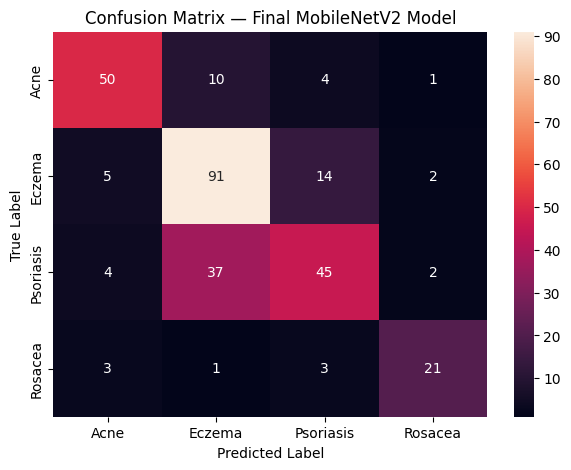

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix — Final MobileNetV2 Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Final Results Interpretation

The final selected model is MobileNetV2 after the first transfer learning phase.

The model achieved a test accuracy of 71%, which is higher than the previous CNN models trained from scratch. The macro F1-score reached 0.72 and the weighted F1-score reached 0.70.

The model performed well on Acne and Rosacea, with F1-scores of 0.79 and 0.78 respectively. Eczema also achieved a good F1-score of 0.73. Psoriasis remained the most difficult class, with an F1-score of 0.58, probably due to visual similarities with other inflammatory skin conditions.

Compared with the Simple CNN and the Improved CNN, MobileNetV2 showed better generalization. This confirms that transfer learning is more suitable for this dermatological image classification task than training a CNN from scratch on a limited dataset.

Fine-tuning was also tested, but it did not improve the overall performance. Therefore, the MobileNetV2 Phase 1 model was selected as the final model.

## Limitations

This project has some limitations:

- The dataset size is limited compared to real clinical datasets.
- Some classes, such as Psoriasis and Eczema, share similar visual patterns.
- The model is not a medical diagnostic tool.
- Image quality, lighting and skin tone variations may affect predictions.
- The system should be validated on larger and more diverse datasets before any real-world use.

## Conclusion

This project demonstrated the use of Deep Learning and Computer Vision for preliminary skin disease image classification.

Several CNN-based models were tested. The Simple CNN showed overfitting, while the Improved CNN did not generalize well. MobileNetV2 transfer learning achieved the best performance with a test accuracy of 71%.

The final model can classify images into four categories: Acne, Eczema, Psoriasis and Rosacea.

Future work may include:
- Using a larger and cleaner dataset
- Adding more skin disease classes
- Testing other architectures such as EfficientNet or Vision Transformers
- Improving model explainability with Grad-CAM
- Integrating the model into a Streamlit web application